# ATAC/RNA example through the cEBMF self-covariate interface

This demonstrates the automatic `cEBMF(..., self_row_cov=True)` route using the existing
neural CGB gates and HMM feature priors. Start with `QUICK=True` after an editable install
and kernel restart in your `cebmf` environment.

Here RNA conditions on a **fixed fitted ATAC loading matrix**. Each matrix has full
joint inference within its own L/F hierarchy, but these two cEBMF calls do not propagate
RNA evidence back to uncertain ATAC loadings. For that full coupled model, run the
separate `ATAC_RNA_hmm_joint.ipynb` notebook, which uses `JointATACRNA` and supports
partially overlapping sample IDs. Both examples use the existing neural gates.


In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

root = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "examples" / "run_tree_joint.py").exists()), None)
if root is None:
    raise RuntimeError("Open this notebook inside the cebmf_torch checkout.")
sys.path.insert(0, str(root / "examples"))
torch.set_num_threads(1)
print("Python:", sys.executable)
from cebmf_torch import cEBMF
from cebmf_torch.experimental.data import simulate_atac_rna


Python: C:\Users\willi\miniconda3\envs\cebmf\python.exe


In [2]:
QUICK = True
SEED = 1
N, P = (400, 200) if QUICK else (2000, 1000)
ROUNDS = 3 if QUICK else 8
joint_settings = dict(initialization_iterations=5 if QUICK else 10,
                      pretrain_steps=50 if QUICK else 100,
                      burnin=30 if QUICK else 100, draws=40 if QUICK else 150,
                      thin=1 if QUICK else 2, progress_every=25, seed=SEED + 100)
sim = simulate_atac_rna(N, P, seed=SEED)
common = dict(K=5, prior_L="cgb", prior_F="hmm_pos", self_row_cov=True,
              prior_F_kwargs={"half_grid": 8, "maxiter": 20}, S=1.5, device="cpu",
              joint_kwargs=joint_settings)


In [3]:
atac_model = cEBMF(sim["atac"], **common)
atac_model.initialise_factors()
atac_result = atac_model.fit(ROUNDS)

# Rows are fully paired in this example. Clone once; keep X_l fixed during RNA inference.
rna_model = cEBMF(sim["rna"], X_l=atac_result.L.detach().clone(), **common)
rna_model.initialise_factors()
rna_result = rna_model.fit(ROUNDS)
print("Inference:", atac_result.inference, rna_result.inference)
for name, result in (("atac", atac_result), ("rna", rna_result)):
    rmse = (result.reconstruction - sim[f"signal_{name}"]).square().mean().sqrt()
    print(name.upper(), "signal RMSE:", float(rmse))


C:\Document\Serieux\Travail\python_work\package\cebmf_torch\src\cebmf_torch\cebmf\cebmf.py:247: UserWarning: Self-covariates selected joint sampling. fit(maxit) now uses maxit prior-learning rounds, then burn-in and retained draws from joint_kwargs. Rank, noise and non-neural priors stay fixed; history_obj records sampled log joint densities, not an ELBO.
  self._ensure_joint_sampler()
Joint sweep 25/70; kept 0 draws
Joint sweep 50/70; kept 20 draws
Joint sweep 25/70; kept 0 draws
Joint sweep 50/70; kept 20 draws
Inference: joint joint
ATAC signal RMSE: 0.10768268701453562
RNA signal RMSE: 0.13478428114423288


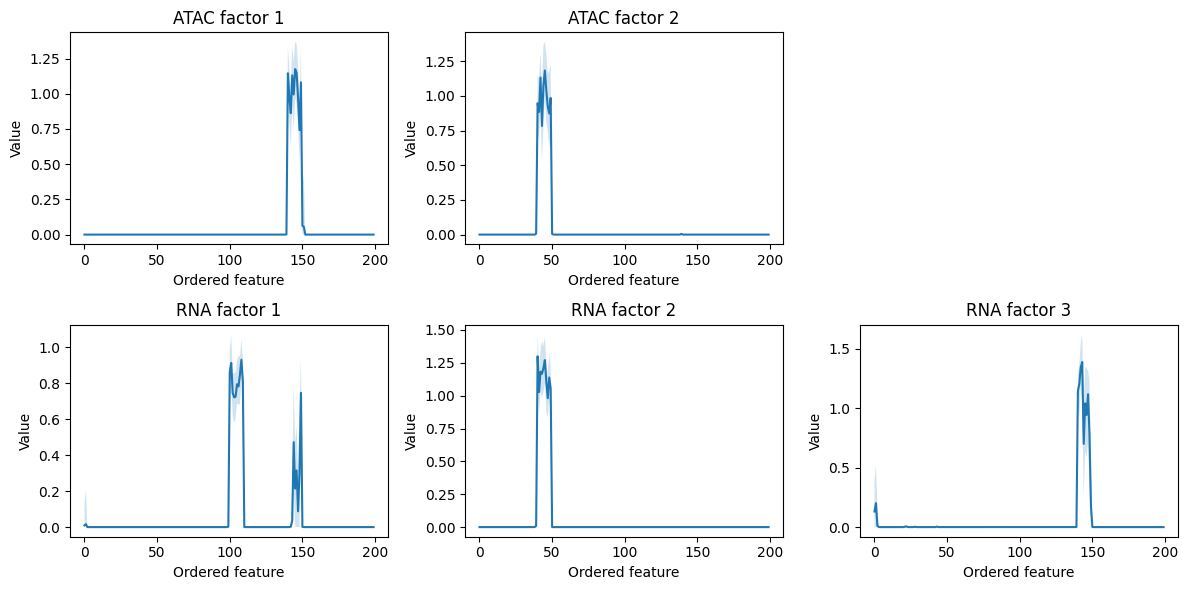

In [4]:
rank = max(atac_result.F.shape[1], rna_result.F.shape[1])
fig, axes = plt.subplots(2, rank, figsize=(4 * rank, 6), squeeze=False)
for row, (name, result) in enumerate((("ATAC", atac_result), ("RNA", rna_result))):
    for k, ax in enumerate(axes[row]):
        if k >= result.F.shape[1]:
            ax.set_visible(False)
            continue
        post = result.joint_posterior
        lo, hi = post.factor_draws[:, :, k].quantile(torch.tensor([0.025, 0.975], dtype=torch.float64), dim=0)
        ax.fill_between(range(P), lo.numpy(), hi.numpy(), alpha=0.2)
        ax.plot(result.F[:, k].numpy())
        ax.set(title=f"{name} factor {k + 1}", xlabel="Ordered feature", ylabel="Value")
fig.tight_layout()
plt.show()


## Interpretation and next checks

Use `result.reconstruction`, which preserves posterior dependence between L and F.
`result.L @ result.F.T` generally differs. Pointwise intervals condition on fitted
hyperparameters and, for RNA in this example, the fixed supplied ATAC loadings.
The log-joint trace fluctuates during sampling; it is not an optimization loss.

All eight learned scalar families are supported on either hierarchical axis; `norm`
and HMM priors are also supported on the opposite axis. The current joint route is CPU
only and does not yet implement exponential mixtures, linear-logistic CGB or VampPrior.
The original variational route remains active when neither effective self-covariate flag is set.
